# 虛擬環境與環境配置

此部分設定 Python 虛擬環境並安裝 Jupyter Kernel，確保代碼運行環境與依賴於獨立隔離。

## 步驟說明
1. **檢查 Python 版本**: 驗證系統 Python 或指定 Python 的版本
2. **創建虛擬環境**: 使用 `python -m venv` 創建 `Project` 目錄為虛擬環境
3. **升級 pip**: 確保套件安裝工具為最新版本
4. **安裝 ipykernel**: 使虛擬環境可被 Jupyter 識別
5. **註冊 Kernel**: 將環境註冊為 Jupyter Kernel，便於 Notebook 中選擇

## 使用建議
- 若已有虛擬環境，可直接在 VS Code 中選擇 `Project` Kernel
- 若遇到環境問題，刪除 `Project` 資料夾後重新執行此單元


In [1]:
import os
import sys
import subprocess
from pathlib import Path
import shutil
from typing import Optional

# ==========================================
# 設定區
# ==========================================
# 如果您想指定特定版本的 Python (例如 3.10)，請在此填入 python.exe 的完整路徑
# 例如: TARGET_PYTHON_PATH = r"C:\Python310\python.exe"
# 如果設為 None，將使用當前執行此腳本的 Python 版本
TARGET_PYTHON_PATH: Optional[str] = None 
# ==========================================

def get_python_exec() -> str:
    """決定要使用哪個 Python 執行檔來建立環境"""
    if TARGET_PYTHON_PATH and os.path.exists(TARGET_PYTHON_PATH):
        return TARGET_PYTHON_PATH
    
    # 如果沒有指定，使用當前的 sys.executable
    return sys.executable

def check_python_version(python_path: str) -> str:
    """檢查並顯示選定 Python 的版本"""
    try:
        result = subprocess.run(
            [python_path, "--version"], 
            capture_output=True, 
            text=True, 
            check=True
        )
        return result.stdout.strip()
    except Exception:
        return "Unknown Version"

def run_command(command: str, description: str) -> None:
    """執行指令並即時顯示輸出，避免看起來像卡死"""
    print(f"⏳ [{description}]...")
    
    try:
        # 修改：強制指定 encoding='utf-8' 並忽略錯誤 (errors='replace')
        # 這能解決 Windows CP950 與 pip 輸出編碼不一致導致的崩潰
        process = subprocess.Popen(
            command,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
            shell=True if os.name == 'nt' else False,
            encoding='utf-8',       # 強制 UTF-8
            errors='replace'        # 遇到無法解碼的字符用 ? 取代，防止報錯
        )

        while True:
            if process.stdout is None:
                break
            output = process.stdout.readline()
            if output == '' and process.poll() is not None:
                break
            if output:
                print(f"  | {output.strip()}")
        
        rc = process.poll()
        if rc is not None and rc != 0:
            if process.stderr is not None:
                err = process.stderr.read()
                print(f"❌ [{description}] 失敗！錯誤訊息：\n{err}")
            raise subprocess.CalledProcessError(rc, command)
            
        print(f"✅ [{description}] 完成。\n")
        
    except Exception as e:
        print(f"執行時發生錯誤: {e}")
        raise e

def setup_project_env() -> None:
    venv_name = "Project"
    base_path = Path.cwd()
    venv_path = base_path / venv_name
    
    # 決定來源 Python (用來創建環境的母體)
    source_python = get_python_exec()
    source_version = check_python_version(source_python)
    
    # 決定目標 Python (虛擬環境內的 Python)
    venv_python = str(venv_path / "Scripts" / "python.exe")

    print(f"=== 🚀 開始設定虛擬環境: {venv_name} ===")
    print(f"工作目錄: {base_path}")
    print(f"來源 Python: {source_python}")
    print(f"版本資訊: {source_version}")
    print("-" * 40)

    # 1. 檢查並創建虛擬環境
    if not venv_path.exists():
        # 使用 source_python 來執行 -m venv，這樣就會創建該版本的環境
        cmd_str = f'"{source_python}" -m venv "{venv_name}"'
        run_command(cmd_str, f"創建虛擬環境 (基於 {source_version})")
    else:
        print(f"✅ [1/4] 虛擬環境 '{venv_name}' 已存在，跳過創建。")
        # 檢查已存在的環境版本是否與預期相符
        if os.path.exists(venv_python):
            existing_ver = check_python_version(venv_python)
            print(f"      (現有環境版本: {existing_ver})")
        print("\n")

    if not os.path.exists(venv_python):
        print(f"❌ 嚴重錯誤：找不到 {venv_python}")
        print("請嘗試刪除 Project 資料夾後重試。")
        return

    # 2. 升級 pip
    pip_cmd = f'"{venv_python}" -m pip install --upgrade pip --no-warn-script-location'
    run_command(pip_cmd, "2/4 升級 pip")

    # 3. 安裝 ipykernel
    kernel_cmd = f'"{venv_python}" -m pip install ipykernel --no-warn-script-location'
    run_command(kernel_cmd, "3/4 安裝 ipykernel")

    # 4. 註冊 Kernel
    display_name = f"Python ({venv_name})"
    register_cmd = f'"{venv_python}" -m ipykernel install --user --name {venv_name} --display-name "{display_name}"'
    run_command(register_cmd, "4/4 註冊 Jupyter Kernel")

    print("="*60)
    print("🎉 設定全部完成！")
    print(f"建立的版本: {source_version}")
    print(f"現在請依照以下步驟啟用環境：")
    print(f"1. 點擊 VS Code 右上角的 'Select Kernel'")
    print(f"2. 選擇 '{display_name}'")
    print(f"3. 或是使用魔術指令安裝套件： %pip install -r requirements.txt")
    print("="*60)

if __name__ == "__main__":
    setup_project_env()


=== 🚀 開始設定虛擬環境: Project ===
工作目錄: c:\Clark\YZU\Papper\Code
來源 Python: c:\Clark\YZU\Papper\Code\Project\Scripts\python.exe
版本資訊: Python 3.11.9
----------------------------------------
✅ [1/4] 虛擬環境 'Project' 已存在，跳過創建。
      (現有環境版本: Python 3.11.9)


⏳ [2/4 升級 pip]...
  | Requirement already satisfied: pip in .\Project\Lib\site-packages (26.0.1)
✅ [2/4 升級 pip] 完成。

⏳ [3/4 安裝 ipykernel]...
  | Requirement already satisfied: ipykernel in .\Project\Lib\site-packages (6.29.5)
  | Requirement already satisfied: comm>=0.1.1 in .\Project\Lib\site-packages (from ipykernel) (0.2.3)
  | Requirement already satisfied: debugpy>=1.6.5 in .\Project\Lib\site-packages (from ipykernel) (1.8.20)
  | Requirement already satisfied: ipython>=7.23.1 in .\Project\Lib\site-packages (from ipykernel) (9.9.0)
  | Requirement already satisfied: jupyter-client>=6.1.12 in .\Project\Lib\site-packages (from ipykernel) (7.4.9)
  | Requirement already satisfied: jupyter-core!=5.0.*,>=4.12 in .\Project\Lib\site-packages (f

# 環境套件安裝

使用魔術指令 `%pip` 安裝 `requirements.txt` 中列出的所有依賴套件至當前 Kernel 環境。

## 套件清單
詳見 [requirements.txt](requirements.txt)，包括：
- 數據處理: pandas, numpy
- 金融數據: yfinance
- 統計分析: statsmodels, scipy
- 機器學習: scikit-learn, torch
- 時間序列: dtaidistance
- 繪圖: matplotlib, seaborn
- 其他: requests, beautifulsoup4

## 執行提示
- 第一次執行可能需要稍候，因為需要下載編譯大型套件 (如 torch、scikit-learn)
- 若個別套件安裝失敗，可以逐一檢查或手動安裝


In [2]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


# 配對交易回測框架執行


## 環境初始化與庫導入

導入所有必要的 Python 庫並進行環境配置，包括：
- **系統庫**: os, json, traceback, warnings
- **數據處理**: pandas, numpy
- **金融數據**: yfinance, requests
- **統計分析**: statsmodels, scipy
- **機器學習**: scikit-learn (SVM, DBSCAN, PCA, RandomForest, MLP)
- **時間序列**: dtaidistance (DTW 計算)
- **繪圖**: matplotlib, seaborn

同時設定中文字體支援和 Seaborn 風格。


In [3]:
# -*- coding: utf-8 -*-
from abc import ABC, abstractmethod
from typing import Dict, List, Tuple, Optional, Union, Any
from datetime import datetime
import datetime as dt
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint, adfuller
from scipy import stats
from sklearn.svm import OneClassSVM
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import warnings
import traceback
import requests
import io
import os
import json

# ============ 環境配置 ============
try:
    from IPython.display import display as display_func
except ImportError:
    def display_func(x: Any) -> None:
        print(x)

warnings.filterwarnings("ignore")

try:
    plt.style.use('seaborn-v0_8')
except:
    plt.style.use('ggplot')

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Microsoft JhengHei', 'SimHei', 'WenQuanYi Micro Hei', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = 'data'
if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)
    print(f"[系統資訊] 已建立資料儲存目錄: {DATA_DIR}")


## 核心工具函數與基礎類別

本段實作了配對交易框架的基礎組件：

### 主要功能
1. **`get_sp500_tickers()`**: 從 Wikipedia 獲取 S&P 500 成分股列表，支援本地緩存加速重複執行
2. **`DistanceUtils`**: 距離計算工具箱，包含傳統歐幾里得距離與 DTW (動態時間規畫) 距離
3. **`DataHandler`**: 股價數據下載、緩存與滾動視窗生成
   - 下載調整收盤價 (Adj Close)
   - 自動處理缺失數據 (前向填充、後向填充)
   - 生成 252 天 (年度) 形成期 + 126 天 (半年) 交易期的滾動視窗
4. **`Strategy`** (抽象基類): 所有配對交易策略的基礎類別
   - 定義 `train()` 和 `get_signals()` 的接口
   - 實作共用方法 `_calculate_ssd()` 計算配對距離排名

### 設計理念
- **模塊化**: 每個組件獨立，便於擴展新策略
- **向量化**: 使用 NumPy/Pandas 向量化操作提高運行效率
- **容錯性**: 數據下載失敗自動降級，連接超時自動重試


In [4]:
def get_sp500_tickers(filename: str = 'sp500_tickers.json') -> List[str]:
    """從 Wikipedia 獲取 S&P 500 成分股列表並進行本地緩存。"""
    cache_file = os.path.join(DATA_DIR, filename)

    if os.path.exists(cache_file):
        try:
            with open(cache_file, 'r') as f:
                tickers = json.load(f)
            return tickers
        except Exception:
            pass

    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    headers = {'User-Agent': 'Mozilla/5.0'}
    try:
        response = requests.get(url, headers=headers, timeout=10)
        tables = pd.read_html(io.StringIO(response.text))
        df = tables[0]
        tickers = df['Symbol'].tolist()
        clean_tickers = [ticker.replace('.', '-') for ticker in tickers]
        
        with open(cache_file, 'w') as f:
            json.dump(clean_tickers, f)
        print(f"[系統資訊] 成功獲取 {len(clean_tickers)} 檔股票代碼並儲存至 {cache_file}。")
        return clean_tickers
    except Exception as e:
        print(f"[錯誤] 獲取 S&P 500 列表失敗: {e}")
        return []

class DistanceUtils:
    """距離計算工具箱，包含 DTW 邏輯。"""
    @staticmethod
    def calculate_dtw(series_a: np.ndarray, series_b: np.ndarray) -> float:
        """計算動態時間規畫距離。"""
        try:
            from dtaidistance import dtw
            return float(dtw.distance(series_a.astype(np.float64), series_b.astype(np.float64)))
        except ImportError:
            return DistanceUtils._dtw_numpy(series_a, series_b)

    @staticmethod
    def _dtw_numpy(s1: np.ndarray, s2: np.ndarray) -> float:
        """原生 NumPy DTW 實作。"""
        r, c = len(s1), len(s2)
        D0 = np.zeros((r + 1, c + 1))
        D0[0, 1:] = np.inf
        D0[1:, 0] = np.inf
        D = D0[1:, 1:]
        
        dist_matrix = (s1[:, None] - s2[None, :]) ** 2
        
        for i in range(r):
            for j in range(c):
                cost = dist_matrix[i, j]
                D[i, j] = cost + min(D0[i, j], D0[i+1, j], D0[i, j+1])
        
        return float(np.sqrt(D[r-1, c-1]))

class DataHandler:
    """數據下載、緩存與視窗生成。"""
    def __init__(self, tickers: List[str], start_date: str, end_date: str) -> None:
        self.tickers = tickers
        self.start_date = start_date
        self.end_date = end_date
        self.cache_file = os.path.join(DATA_DIR, f'sp500_data_{start_date}_{end_date}.pkl')
        self.data: Optional[pd.DataFrame] = None

    def fetch_data(self) -> pd.DataFrame:
        """下載或讀取歷史股價數據 (Adj Close)。"""
        if os.path.exists(self.cache_file):
            print(f"[資料載入] 發現本地緩存 {self.cache_file}，正在讀取...")
            try:
                cached_data = pd.read_pickle(self.cache_file)
                if not cached_data.empty:
                    self.data = cached_data
                    print(f"[資料載入] 緩存讀取成功。數據矩陣形狀: {self.data.shape}")
                    return self.data
            except Exception as e:
                print(f"[資料載入] 緩存讀取失敗 ({e})，準備重新下載...")

        print(f"[資料下載] 開始下載數據 ({self.start_date} 到 {self.end_date})，共 {len(self.tickers)} 檔...")
        try:
            full_data = yf.download(self.tickers, start=self.start_date, end=self.end_date, progress=True, auto_adjust=False)
            
            if full_data is None or full_data.empty:
                return pd.DataFrame()

            if isinstance(full_data.columns, pd.MultiIndex):
                if 'Adj Close' in full_data.columns.get_level_values(0):
                    raw_data = full_data['Adj Close']
                elif 'Close' in full_data.columns.get_level_values(0):
                    raw_data = full_data['Close']
                else:
                    raw_data = full_data
            else:
                if 'Adj Close' in full_data.columns:
                    raw_data = full_data['Adj Close']
                elif 'Close' in full_data.columns:
                    raw_data = full_data['Close']
                else:
                    raw_data = full_data

            if isinstance(raw_data, pd.Series):
                raw_data = raw_data.to_frame()
            
            self.data = raw_data.ffill().bfill()
            threshold = len(self.data) * 0.9
            self.data = self.data.dropna(axis=1, thresh=int(threshold))
            
            self.data.to_pickle(self.cache_file)
            print(f"[資料下載] 下載完成並已緩存至 {self.cache_file}。有效股票: {self.data.shape[1]}")
            return self.data
            
        except Exception as e:
            print(f"[錯誤] 數據下載失敗: {e}")
            traceback.print_exc()
            return pd.DataFrame()

    @staticmethod
    def get_rolling_windows(data: pd.DataFrame, formation_days: int = 252, 
                            trading_days: int = 126) -> List[Dict[str, Any]]:
        """生成滾動回測視窗。"""
        n = len(data)
        indices: List[Dict[str, Any]] = []
        step = trading_days
        
        if n < formation_days + trading_days:
            return []

        for start_idx in range(0, n - formation_days - trading_days, step):
            form_start = start_idx
            form_end = start_idx + formation_days
            trade_start = form_end
            trade_end = form_end + trading_days
            
            indices.append({
                'form_start': data.index[form_start],
                'form_end': data.index[form_end],
                'trade_start': data.index[trade_start],
                'trade_end': data.index[trade_end]
            })
        return indices

class Strategy(ABC):
    """配對交易策略的抽象基礎類別。"""
    def __init__(self, name: str, num_pairs: int = 20) -> None:
        self.name = name
        self.num_pairs = num_pairs
        self.pairs: List[Dict[str, Any]] = []

    @abstractmethod
    def train(self, formation_data: pd.DataFrame) -> None:
        raise NotImplementedError

    @abstractmethod
    def get_signals(self, trading_data: pd.DataFrame) -> pd.Series:
        raise NotImplementedError

    def _calculate_ssd(self, price_df: pd.DataFrame, top_n_filter: int = 500) -> List[Tuple[str, str, float]]:
        """計算平方差和距離"""
        norm_prices = price_df / price_df.iloc[0]
        returns = price_df.pct_change().fillna(0)
        
        valid_cols = returns.columns[returns.std() > 1e-6]
        returns = returns[valid_cols]
        norm_prices = norm_prices[valid_cols]
        
        corr_matrix = returns.corr().fillna(-1)
        corr_pairs = (corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
                      .stack()
                      .sort_values(ascending=True)
                      .head(top_n_filter))
        
        candidates: List[Tuple[str, str, float]] = []
        for (s1, s2), _ in corr_pairs.items():
            ssd = float(((norm_prices[s1] - norm_prices[s2]) ** 2).sum())
            candidates.append((s1, s2, ssd))
            
        candidates.sort(key=lambda x: x[2])
        return candidates


## 策略 1: 距離法 (Distance Strategy)

### 核心原理
此策略基於歷史價格相似性配對，假設走勢相近的股票對存在均值迴歸特性。

#### 配對選擇
- 計算歷史期間所有股票對的 **SSD** (平方和距離)
- SSD = $\sum_{t} (P1_t - P2_t)^2$，值越小說明股票對走勢越接近
- 选取 SSD 最小的 N 對作為交易配對

#### 交易邏輯
- **價差 (Spread)** = Norm$_1$ - Norm$_2$ (歸一化價格差)
- **進場條件**:
  - 做多: Spread < -2σ (σ = 價差標準差)
  - 做空: Spread > +2σ
- **平倉條件**: Spread 回升至接近 0 時 (通常 < 0.5σ)
- **對沖**: 簡單 1:1 對沖，各持倉 50%

#### 優缺點
| 優點 | 缺點 |
|------|------|
| 計算快速簡潔 | 忽視真實統計關係 |
| 無需參數調優 | 易受偽配對陷阱 |
| 初期篩選有效 | 未考慮動態對沖比率 |


In [5]:
class DistanceStrategy(Strategy):
    def __init__(self, num_pairs: int = 20, entry_sigma: float = 2.0, 
                 exit_sigma: float = 0.0, transaction_cost_bps: float = 25.0) -> None:
        super().__init__("Basic: Distance", num_pairs)
        self.entry_sigma = entry_sigma
        self.exit_sigma = exit_sigma
        self.transaction_cost_bps = transaction_cost_bps  # 會被 Backtester 方法覆蓋（若已提供 common_params）

    def train(self, formation_data: pd.DataFrame) -> None:
        # SSD 配對篩選
        ranked_pairs = self._calculate_ssd(formation_data)
        top_pairs = ranked_pairs[:self.num_pairs]
        self.pairs = []
        
        # 計算每對配對的標準差
        norm_data = formation_data / formation_data.iloc[0]
        for s1, s2, ssd in top_pairs:
            spread = norm_data[s1] - norm_data[s2]
            std_dev = float(spread.std())
            self.pairs.append({
                's1': s1, 's2': s2, 'std': std_dev, 'ssd': ssd,
                'metric_value': ssd, 'metric_name': 'SSD'
            })

    def get_signals(self, trading_data: pd.DataFrame) -> pd.Series:
        # 向量化交易邏輯
        daily_rets = pd.Series(0.0, index=trading_data.index)
        cost_multiplier = self.transaction_cost_bps / 10000.0
        norm_trade_data = trading_data / trading_data.iloc[0]
        returns = trading_data.pct_change().fillna(0)
        
        for pair in self.pairs:
            s1, s2 = pair['s1'], pair['s2']
            if s1 not in norm_trade_data.columns or s2 not in norm_trade_data.columns: 
                continue
            
            spread = norm_trade_data[s1] - norm_trade_data[s2]
            threshold = self.entry_sigma * pair['std']
            
            # 生成進場信號
            long_signal = spread < -threshold
            short_signal = spread > threshold
            exit_signal = np.abs(spread) <= self.exit_sigma * pair['std']
            
            # 狀態轉移迴圈
            position = np.zeros(len(spread))
            for i in range(1, len(spread)):
                if position[i-1] == 0:
                    if long_signal.iloc[i]: position[i] = 1
                    elif short_signal.iloc[i]: position[i] = -1
                else:
                    if exit_signal.iloc[i]: position[i] = 0
                    else: position[i] = position[i-1]
            
            # 計算損益與交易成本
            position_series = pd.Series(position, index=spread.index)
            position_shift = position_series.shift(1).fillna(0)
            position_change = position_shift.diff().fillna(0)
            price_pnl = position_shift * (returns[s1] - returns[s2])
            trade_cost = np.abs(position_change) * cost_multiplier
            
            daily_rets += (price_pnl - trade_cost) / self.num_pairs
        
        return daily_rets


## 策略 2: 協整法 (Cointegration Strategy)

### 核心原理
此策略基於統計協整檢定，確保配對股票存在長期均衡關係。相比距離法更科學，引入對沖比率動態調整。

#### 配對選擇
1. 計算對數價格: $\log P1, \log P2$
2. **協整檢定** (Johansen / Engle-Granger): p-value < 0.05 判定為協整
3. **線性回歸**: $\log P1 = \alpha + \beta \cdot \log P2$
4. **殘差提取**: $e_t = \log P1_t - (\alpha + \beta \log P2_t)$

#### 交易邏輯
- **Z-Score**: $Z_t = \frac{e_t - \mu}{\sigma}$ (標準化殘差)
- **進場條件**:
  - 做多: $Z_t < -2$ (Stock_1 被高估相對 Stock_2)
  - 做空: $Z_t > +2$ (Stock_1 被低估相對 Stock_2)
- **平倉條件**: $|Z_t| < 0.5$ 時平倉
- **對沖比率**: $\beta$ 自動計算，對沖比例為 $1:\beta$

#### 優缺點
| 優點 | 缺點 |
|------|------|
| 基於統計檢定，更嚴謹 | 協整關係非恆定，易隨時間變化 |
| 動態對沖比率，充分利用槓桿 | 需充足歷史數據估計參數 |
| 減少偽配對陷阱 | 市場結構變化可能破壞協整性 |


In [6]:
class CointegrationStrategy(Strategy):
    def __init__(self, num_pairs: int = 20, entry_z: float = 2.0, 
                 exit_z: float = 0.0, transaction_cost_bps: float = 25.0) -> None:
        super().__init__("Basic: Cointegration", num_pairs)
        self.entry_z = entry_z
        self.exit_z = exit_z
        self.transaction_cost_bps = transaction_cost_bps  # 會被 Backtester 方法覆蓋（若已提供 common_params）

    def train(self, formation_data: pd.DataFrame) -> None:
        # SSD 預篩選
        ranked_pairs = self._calculate_ssd(formation_data)
        self.pairs = []
        log_prices = np.log(formation_data.clip(lower=0.01))
        
        # 逐對檢驗協整性
        for s1, s2, ssd in ranked_pairs:
            if len(self.pairs) >= self.num_pairs: 
                break
            if float(log_prices[s1].std()) < 1e-4 or float(log_prices[s2].std()) < 1e-4: 
                continue
            
            # Engle-Granger 協整檢定
            try:
                score, pvalue, _ = coint(log_prices[s1], log_prices[s2])
            except: 
                continue
            
            # p-value < 0.05 時接受協整
            if pvalue < 0.05:
                # OLS 回歸計算對沖比率
                model = sm.OLS(log_prices[s1], sm.add_constant(log_prices[s2])).fit()
                beta = float(model.params.iloc[1])
                alpha = float(model.params.iloc[0])
                
                # 提取殘差統計
                residuals = log_prices[s1] - (alpha + beta * log_prices[s2])
                self.pairs.append({
                    's1': s1, 's2': s2, 'beta': beta, 'alpha': alpha,
                    'mu': float(residuals.mean()), 'sigma': float(residuals.std()),
                    'metric_value': float(pvalue), 'metric_name': 'P-value'
                })

    def get_signals(self, trading_data: pd.DataFrame) -> pd.Series:
        # 向量化交易邏輯
        daily_rets = pd.Series(0.0, index=trading_data.index)
        cost_multiplier = self.transaction_cost_bps / 10000.0
        log_trade = np.log(trading_data.clip(lower=0.01))
        returns = trading_data.pct_change().fillna(0)
        
        for pair in self.pairs:
            s1, s2 = pair['s1'], pair['s2']
            if s1 not in log_trade.columns or s2 not in log_trade.columns: 
                continue
            
            # 計算 Z-Score
            residuals = log_trade[s1] - pair['beta'] * log_trade[s2] - pair['alpha']
            z_scores = (residuals - pair['mu']) / pair['sigma']
            
            # 生成進場信號
            long_signal = z_scores < -self.entry_z
            short_signal = z_scores > self.entry_z
            exit_signal = np.abs(z_scores) <= self.exit_z
            
            # 狀態轉移迴圈
            position = np.zeros(len(z_scores))
            for i in range(1, len(z_scores)):
                if position[i-1] == 0:
                    if long_signal.iloc[i]: position[i] = 1
                    elif short_signal.iloc[i]: position[i] = -1
                else:
                    if exit_signal.iloc[i]: position[i] = 0
                    else: position[i] = position[i-1]
            
            # 計算損益與交易成本
            position_shift = pd.Series(position, index=z_scores.index).shift(1).fillna(0)
            trade_cost = np.abs(position_shift.diff().fillna(0)) * (1 + abs(pair['beta'])) * cost_multiplier
            price_pnl = position_shift * (returns[s1] - pair['beta'] * returns[s2])
            
            daily_rets += (price_pnl - trade_cost) / self.num_pairs
        
        return daily_rets


## 策略 3: SVM 異常檢測 (SVM Strategy)

### 核心原理
結合機器學習 One-Class SVM 的異常檢測，識別「正常」的高質量配對，過濾異常配對。

#### 配對特徵提取
為每對股票計算 6 維特徵向量：
1. **相關係數**: 衡量線性關係强度，$\text{Corr}(r_1, r_2)$
2. **價差標準差**: $\sigma(\text{Spread})$ 衡量配對穩定性
3. **平均絕對價差**: $E[|\text{Spread}|]$ 代表歷史價差水平
4. **波動率比**: $\frac{\sigma_{\Delta P1}}{\sigma_{\Delta P2}}$ 兩股票波動性相對關係
5. **價差方差**: $\text{Var}(\text{Spread})$ 價差變異度
6. **價差範圍**: $\max(\text{Spread}) - \min(\text{Spread})$ 價差極值

#### One-Class SVM 異常檢測
- 訓練 SVM 學習「正常」配對的特徵分佈
- 決策函數值高 = 更接近正常分佈 = 更好的配對
- 計算 SVM 決策函數值，高分配對優先選用

#### 交易邏輯
同距離法 (基於價差的 Z-Score 回歸)

#### 優缺點
| 優點 | 缺點 |
|------|------|
| 综合多维度評估 (6個特徵) | 參數敏感性高 |
| 自動異常檢測，過濾極端配對 | 特徵工程可能不完整 |
| 比單純距離法更穩健 | SVM 核函數選擇影響結果 |


In [7]:
class SVMStrategy(Strategy):
    """SVM 策略 (支持向量機方法)"""
    def __init__(self, num_pairs: int = 20, entry_sigma: float = 2.0, 
                 exit_sigma: float = 0.0, transaction_cost_bps: float = 25.0,
                 svm_nu: float = 0.05) -> None:
        super().__init__("Advance: SVM", num_pairs)
        self.entry_sigma = entry_sigma
        self.exit_sigma = exit_sigma
        self.transaction_cost_bps = transaction_cost_bps  # 會被 Backtester 方法覆蓋（若已提供 common_params）
        self.svm_nu = svm_nu

    def _extract_pair_features(self, price_df: pd.DataFrame, s1: str, s2: str) -> np.ndarray:
        """提取 6 維配對特徵向量"""
        p1 = price_df[s1].values
        p2 = price_df[s2].values
        
        # 歸一化
        p1_norm = p1 / p1[0]
        p2_norm = p2 / p2[0]
        
        spread = p1_norm - p2_norm
        
        # 6 個特徵
        features = np.array([
            float(np.corrcoef(p1, p2)[0, 1]),
            float(np.std(spread)),
            float(np.mean(np.abs(spread))),
            float(np.std(np.diff(p1_norm)) / np.std(np.diff(p2_norm)) + 1e-6),
            float(np.var(spread)),
            float(np.max(spread) - np.min(spread)),
        ])
        
        return features

    def train(self, formation_data: pd.DataFrame) -> None:
        # 預篩選候選配對
        ranked_pairs = self._calculate_ssd(formation_data, top_n_filter=200)
        
        # 提取特徵向量
        features_list: List[np.ndarray] = []
        valid_pairs: List[Tuple[str, str, float]] = []
        
        for s1, s2, ssd in ranked_pairs:
            try:
                features = self._extract_pair_features(formation_data, s1, s2)
                features_list.append(features)
                valid_pairs.append((s1, s2, ssd))
            except Exception:
                continue
        
        # 若特徵不足，降級使用 SSD 方法
        if len(features_list) < 5:
            print("[警告] 有效特徵不足，降級使用 SSD 方法")
            self.pairs = []
            norm_data = formation_data / formation_data.iloc[0]
            
            for s1, s2, ssd in ranked_pairs[:self.num_pairs]:
                spread = norm_data[s1] - norm_data[s2]
                std_dev = float(spread.std())
                self.pairs.append({
                    's1': s1, 's2': s2, 'std': std_dev, 'ssd': ssd,
                    'metric_value': ssd, 'metric_name': 'SSD'
                })
            return
        
        # One-Class SVM 異常檢測
        X = np.array(features_list)
        svm_model = OneClassSVM(kernel='rbf', gamma='auto', nu=self.svm_nu)
        svm_model.fit(X)
        
        # 按決策函數值排序
        svm_scores = svm_model.decision_function(X)
        sorted_indices = np.argsort(-svm_scores)
        
        # 選擇高分配對
        self.pairs = []
        norm_data = formation_data / formation_data.iloc[0]
        
        for idx in sorted_indices[:self.num_pairs]:
            s1, s2, ssd = valid_pairs[idx]
            spread = norm_data[s1] - norm_data[s2]
            std_dev = float(spread.std())
            svm_score = float(svm_scores[idx])
            
            self.pairs.append({
                's1': s1, 's2': s2, 'std': std_dev, 'ssd': ssd,
                'metric_value': svm_score, 'metric_name': 'SVM_Score'
            })

    def get_signals(self, trading_data: pd.DataFrame) -> pd.Series:
        # 交易邏輯同距離法
        daily_rets = pd.Series(0.0, index=trading_data.index)
        cost_multiplier = self.transaction_cost_bps / 10000.0
        
        norm_trade_data = trading_data / trading_data.iloc[0]
        returns = trading_data.pct_change().fillna(0)
        
        for pair in self.pairs:
            s1, s2 = pair['s1'], pair['s2']
            if s1 not in norm_trade_data.columns or s2 not in norm_trade_data.columns:
                continue

            spread = norm_trade_data[s1] - norm_trade_data[s2]
            threshold = self.entry_sigma * pair['std']
            
            long_signal = spread < -threshold
            short_signal = spread > threshold
            exit_signal = np.abs(spread) <= self.exit_sigma * pair['std']
            
            position = np.zeros(len(spread))
            for i in range(1, len(spread)):
                if position[i-1] == 0:
                    if long_signal.iloc[i]: position[i] = 1
                    elif short_signal.iloc[i]: position[i] = -1
                else:
                    if exit_signal.iloc[i]: position[i] = 0
                    else: position[i] = position[i-1]
            
            position_series = pd.Series(position, index=spread.index)
            position_shift = position_series.shift(1).fillna(0)
            position_change = position_shift.diff().fillna(0)
            
            price_pnl = position_shift * (returns[s1] - returns[s2])
            trade_cost = np.abs(position_change) * cost_multiplier
            
            daily_rets += (price_pnl - trade_cost) / self.num_pairs
        
        return daily_rets


## 策略 4: 混合策略 (Hybrid Strategy - SSD + DTW)

### 核心原理
融合靜態相似性 (SSD) 與動態相似性 (DTW) 兩個角度，進行雙重配對評分。

#### 動態時間規畫 (DTW)
相比歐幾里得距離，DTW 對時間漂移不敏感，更好捕捉走勢形態相似性。
- **定義**: $\min_{\text{warping path}} \sum \text{cost}(\text{warping path})$
- **優點**: 允許時間軸拉伸，「形狀」相似即可

#### 配對選擇 (雙重排名)
1. 計算所有候選配對的 **SSD** 和 **DTW**
2. 分別進行排名 (1 = 最佳，N = 最差)
3. **綜合得分** = SSD 排名 + DTW 排名
4. 選擇綜合得分最低(最優) 的 N 對配對

#### 交易邏輯
同距離法 (基於價差的標準差回歸)

#### 優缺點
| 優點 | 缺點 |
|------|------|
| 多角度(靜態+動態)配對評估 | DTW 計算複雜，耗時較長 |
| 平衡並避免過度依賴單一特徵 | 排名綜合方式較簡化 |
| 對時間縮放不敏感 | 需調整兩個指標的相對權重 |


In [8]:
class HybridStrategy(Strategy):
    """混合策略 (SSD+DTW) - 向量化實作。"""
    def __init__(self, num_pairs: int = 20, entry_sigma: float = 2.0, 
                 exit_sigma: float = 0.0, transaction_cost_bps: float = 25.0) -> None:
        super().__init__("Advance: Hybrid", num_pairs)
        self.entry_sigma = entry_sigma
        self.exit_sigma = exit_sigma
        self.transaction_cost_bps = transaction_cost_bps  # 會被 Backtester 方法覆蓋（若已提供 common_params）
    
    def train(self, formation_data: pd.DataFrame) -> None:
        # SSD 預篩選
        candidates = self._calculate_ssd(formation_data, top_n_filter=200)
        
        norm_data = formation_data / formation_data.iloc[0]
        hybrid_candidates: List[Dict[str, Any]] = []
        
        # 計算 SSD 和 DTW
        for s1, s2, ssd in candidates:
            series_a = np.asarray(norm_data[s1].values, dtype=np.float64)
            series_b = np.asarray(norm_data[s2].values, dtype=np.float64)
            dtw_val = DistanceUtils.calculate_dtw(series_a, series_b)
            
            hybrid_candidates.append({
                's1': s1, 's2': s2, 
                'ssd': ssd, 'dtw': dtw_val
            })
            
        df_res = pd.DataFrame(hybrid_candidates)
        if df_res.empty: 
            return

        # 雙重排名機制
        df_res['rank_ssd'] = df_res['ssd'].rank(ascending=True)
        df_res['rank_dtw'] = df_res['dtw'].rank(ascending=True)
        df_res['combined_score'] = df_res['rank_ssd'] + df_res['rank_dtw']
        
        # 選擇綜合得分最低的配對
        top_pairs_df = df_res.sort_values('combined_score').head(self.num_pairs)
        
        self.pairs = []
        for _, row in top_pairs_df.iterrows():
            s1, s2 = row['s1'], row['s2']
            spread = norm_data[s1] - norm_data[s2]
            std_dev = float(spread.std())
            self.pairs.append({
                's1': s1, 's2': s2, 'std': std_dev,
                'metric_value': float(row['combined_score']), 'metric_name': 'Combined_Score'
            })

    def get_signals(self, trading_data: pd.DataFrame) -> pd.Series:
        # 交易邏輯同距離法
        daily_rets = pd.Series(0.0, index=trading_data.index)
        cost_multiplier = self.transaction_cost_bps / 10000.0
        
        norm_trade_data = trading_data / trading_data.iloc[0]
        returns = trading_data.pct_change().fillna(0)
        
        for pair in self.pairs:
            s1, s2 = pair['s1'], pair['s2']
            if s1 not in norm_trade_data.columns or s2 not in norm_trade_data.columns:
                continue

            spread = norm_trade_data[s1] - norm_trade_data[s2]
            threshold = self.entry_sigma * pair['std']
            
            long_signal = spread < -threshold
            short_signal = spread > threshold
            exit_signal = np.abs(spread) <= self.exit_sigma * pair['std']
            
            position = np.zeros(len(spread))
            for i in range(1, len(spread)):
                if position[i-1] == 0:
                    if long_signal.iloc[i]: position[i] = 1
                    elif short_signal.iloc[i]: position[i] = -1
                else:
                    if exit_signal.iloc[i]: position[i] = 0
                    else: position[i] = position[i-1]
            
            position_series = pd.Series(position, index=spread.index)
            position_shift = position_series.shift(1).fillna(0)
            position_change = position_shift.diff().fillna(0)
            
            price_pnl = position_shift * (returns[s1] - returns[s2])
            trade_cost = np.abs(position_change) * cost_multiplier
            
            daily_rets += (price_pnl - trade_cost) / self.num_pairs
        
        return daily_rets


## 策略 5: Copula 方法 (CMPI - Copula Mispricing Index)

### 核心原理
採用 Copula 理論分解聯合分布，捕捉更複雜的依存結構，尤其是尾部相關性。

#### Copula 基礎
- **聯合分布分解**: $F(X,Y) = C(F_X(X), F_Y(Y))$
- **改革**: 盗用秩次轉換和逆正態變換得到特徵變量
- **高斯 Copula**: 假設兩變量的依存結構為高斯 Copula
  - Spearman 相關性 ρ 衡量依存強度

#### CMPI (累積錯誤定價指數)
- $M1_t = P(X回歸 | Y \text{當前走勢})$ (條件概率)
- $M2_t = P(Y回歸 | X \text{當前走勢})$ (條件概率)
- **累積**: $M1^\text{cumsum}_t, M2^\text{cumsum}_t$

#### 交易邏輯
- **做多**: $M1^\text{cumsum}_t > \theta$ 且 $M2^\text{cumsum}_t < -\theta$
- **做空**: $M1^\text{cumsum}_t < -\theta$ 且 $M2^\text{cumsum}_t > \theta$
- **平倉**: 符號相反且幅度較小時平倉

#### 優缺點
| 優點 | 缺點 |
|------|------|
| 深層統計理論，捕捉尾部事件 | 複雜度高，難以理解 |
| 動態適應市場狀況 | 計算耗時，秩次轉換運算量大 |
| 避免假設線性關係 | Copula 參數估計風險大 |


In [9]:
class CopulaStrategy(Strategy):
    """Copula 策略 (CMPI) - 高斯 Copula 方法"""
    def __init__(self, num_pairs: int = 20, open_threshold: float = 0.5,
                 transaction_cost_bps: float = 25.0) -> None:
        super().__init__("Advance: Copula", num_pairs)
        self.open_threshold = open_threshold
        self.transaction_cost_bps = transaction_cost_bps  # 會被 Backtester 方法覆蓋（若已提供 common_params）
        
    def train(self, formation_data: pd.DataFrame) -> None:
        # SSD 預篩選
        ranked_pairs = self._calculate_ssd(formation_data)
        top_pairs = ranked_pairs[:self.num_pairs]
        returns = formation_data.pct_change().dropna()
        self.pairs = []
        
        # 估計 Copula 參數
        for s1, s2, ssd in top_pairs:
            r1 = np.asarray(returns[s1].values, dtype=np.float64)
            r2 = np.asarray(returns[s2].values, dtype=np.float64)
            
            # 轉換為均勻分布 (秩次歸一化)
            u = stats.rankdata(r1) / (len(r1) + 1)
            v = stats.rankdata(r2) / (len(r2) + 1)
            
            # 逆常態變換得到高斯 Copula 特性變量
            x = stats.norm.ppf(u)
            y = stats.norm.ppf(v)
            
            if np.std(x) == 0 or np.std(y) == 0: 
                continue

            # Spearman 相關性
            rho = float(np.corrcoef(x, y)[0, 1])
            if np.isnan(rho): 
                rho = 0.0
            
            self.pairs.append({
                's1': s1, 's2': s2, 'rho': rho,
                'sorted_r1': np.sort(r1), 'sorted_r2': np.sort(r2),
                'metric_value': rho, 'metric_name': 'Rho'
            })

    def _get_conditional_prob_vectorized(self, u: np.ndarray, v: np.ndarray, rho: float) -> np.ndarray:
        """向量化條件機率計算"""
        u = np.clip(u, 0.0001, 0.9999)
        v = np.clip(v, 0.0001, 0.9999)
        with np.errstate(divide='ignore', invalid='ignore'):
            numerator = stats.norm.ppf(u) - rho * stats.norm.ppf(v)
            denominator = np.sqrt(1 - rho**2)
            result = stats.norm.cdf(numerator / denominator) if denominator > 0 else np.full_like(u, 0.5)
            result = np.where(np.isfinite(result), result, 0.5)
        return result

    def get_signals(self, trading_data: pd.DataFrame) -> pd.Series:
        # CMPI 累積錯誤定價指數交易
        daily_rets = pd.Series(0.0, index=trading_data.index)
        cost_multiplier = self.transaction_cost_bps / 10000.0
        returns = trading_data.pct_change().fillna(0)
        
        for pair in self.pairs:
            s1, s2 = pair['s1'], pair['s2']
            if s1 not in returns.columns or s2 not in returns.columns: 
                continue

            rho = pair['rho']
            r1_series = np.asarray(returns[s1].values, dtype=np.float64)
            r2_series = np.asarray(returns[s2].values, dtype=np.float64)
            
            # 秩次轉換為均勻分布
            u_series = np.searchsorted(pair['sorted_r1'], r1_series) / (len(pair['sorted_r1']) + 1)
            v_series = np.searchsorted(pair['sorted_r2'], r2_series) / (len(pair['sorted_r2']) + 1)
            
            # 計算條件機率 (CMPI 分量)
            M1_vals = self._get_conditional_prob_vectorized(u_series, v_series, rho) - 0.5
            M2_vals = self._get_conditional_prob_vectorized(v_series, u_series, rho) - 0.5
            
            M1_cumsum = np.cumsum(M1_vals)
            M2_cumsum = np.cumsum(M2_vals)
            
            # 生成進場信號
            long_signal = (M1_cumsum > self.open_threshold) & (M2_cumsum < -self.open_threshold)
            short_signal = (M1_cumsum < -self.open_threshold) & (M2_cumsum > self.open_threshold)
            exit_signal = ((M1_cumsum * M2_cumsum <= 0) & (np.abs(M1_cumsum) < 0.2))
            
            position = np.zeros(len(r1_series))
            for i in range(1, len(r1_series)):
                if position[i-1] == 0:
                    if long_signal[i]: position[i] = 1
                    elif short_signal[i]: position[i] = -1
                else:
                    if exit_signal[i]: position[i] = 0
                    else: position[i] = position[i-1]
            
            position_series = pd.Series(position, index=returns.index)
            position_shift = position_series.shift(1).fillna(0)
            position_change = position_shift.diff().fillna(0)
            
            price_pnl = position_shift * (returns[s1] - returns[s2])
            trade_cost = np.abs(position_change) * cost_multiplier
            
            daily_rets += (price_pnl - trade_cost) / self.num_pairs
        
        return daily_rets


## 策略 6: ML - 隨機森林信號過濾 (RandomForest Signal Strategy)

### 核心原理
在協整法基礎上疊加機器學習，使用隨機森林過濾虛假信號，提高交易勝率。

#### 特徵工程
基於價差 (Spread) 的滯後項和統計量：
- **滯後特徵**: 前 1、2 期價差
- **移動平均**: 5 期滑動平均
- **波動率**: 5 期滑動標準差
- **變化率**: 當期 vs 前期價差

#### 隨機森林訓練
- **目標**: 預測下一期 Z-Score 的上升/下降 (二分類)
- **訓練數據**: 協整法優質配對的 Spread 序列
- **超參數**: n_estimators=50, max_depth=3 (防止過擬合)

#### 交易邏輯 (聯合過濾)
結合統計信號與 ML 預測：
- **做多**: $Z < -2$ **且** ML 預測 Z 會上升 (概率 > 0.5)
- **做空**: $Z > +2$ **且** ML 預測 Z 會下降 (概率 < 0.5)
- 減少虛假信號，提高信號可靠性

#### 優缺點
| 優點 | 缺點 |
|------|------|
| 減少虛假信號，提高勝率 | 過擬合風險較高 |
| 特徵學習自動化 | 需充足訓練數據 |
| 實證有效 | 隨機性可能導致結果不穩定 |


## 策略 7: ML - 隨機森林信號過濾策略

### 交易邏輯說明
- **基礎配對**: 先使用協整法選出優質配對
- **特徵工程**: 對每對股票的殘差 (Spread) 計算：
  - 1,2 期滯後值
  - 5 期滑動平均
  - 5 期滑動標準差
  - 價差變化
- **監督學習**: 訓練隨機森林預測下一期 Z-Score 方向（上升/下降）
- **聯合過濾**: 結合 Z-Score 信號與 ML 預測：
  - Z < -2 **且** ML 預測上升 → 做多
  - Z > +2 **且** ML 預測下降 → 做空
  
### 優點
- **減少虛假信號**: ML 過濾掉不可靠的 Z-Score 極值
- **特徵學習**: 捕捉 Spread 的動態人型
- **實證有效**: 限制交易次數，降低交易成本

### 缺點
- 模型過擬合風險
- 需要足夠訓練數據
- 隨機性可能導致不同運行結果不同

In [10]:
class RandomForestSignalStrategy(Strategy):
    """ML: 隨機森林信號過濾策略"""
    def __init__(self, num_pairs: int = 20, entry_z: float = 2.0) -> None:
        super().__init__("ML: RandomForest", num_pairs)
        self.entry_z = entry_z
        self.models = {}

    def _create_features(self, spread: pd.Series) -> pd.DataFrame:
        """特徵工程: 滯後項、移動統計量"""
        df = pd.DataFrame(index=spread.index)
        df['spread_lag1'] = spread.shift(1)
        df['spread_lag2'] = spread.shift(2)
        df['spread_ma5'] = spread.shift(1).rolling(5).mean()
        df['spread_std5'] = spread.shift(1).rolling(5).std()
        df['spread_diff'] = spread.shift(1) - spread.shift(2)
        return df.fillna(0)

    def train(self, formation_data: pd.DataFrame) -> None:
        # 基準: 協整法配對
        base_strat = CointegrationStrategy(self.num_pairs)
        base_strat.train(formation_data)
        self.pairs = base_strat.pairs
        self.models = {}
        
        log_prices = np.log(formation_data.clip(lower=0.01))
        
        # 訓練每對配對的隨機森林
        for pair in self.pairs:
            s1, s2 = pair['s1'], pair['s2']
            residuals = log_prices[s1] - pair['beta'] * log_prices[s2] - pair['alpha']
            z_scores = (residuals - pair['mu']) / pair['sigma']
            
            # 特徵工程
            X = self._create_features(z_scores)
            # 目標: 預測下一期 Z-score 的上升方向
            Y = (z_scores.shift(-1) > z_scores).astype(int)
            
            # 移除最後一行
            X = X.iloc[:-1]
            Y = Y.iloc[:-1]
            
            if len(X) > 50:
                clf = RandomForestClassifier(n_estimators=50, max_depth=3, random_state=42)
                clf.fit(X, Y)
                self.models[(s1, s2)] = clf

    def get_signals(self, trading_data: pd.DataFrame) -> pd.Series:
        daily_rets = pd.Series(0.0, index=trading_data.index)
        log_trade = np.log(trading_data.clip(lower=0.01))
        returns = trading_data.pct_change().fillna(0)
        
        for pair in self.pairs:
            s1, s2 = pair['s1'], pair['s2']
            if s1 not in log_trade.columns or s2 not in log_trade.columns: 
                continue
            
            # 計算 Z-Score
            residuals = log_trade[s1] - pair['beta'] * log_trade[s2] - pair['alpha']
            z_scores = (residuals - pair['mu']) / pair['sigma']
            
            # ML 預測
            if (s1, s2) in self.models:
                X_live = self._create_features(z_scores)
                pred_direction = self.models[(s1, s2)].predict(X_live)
                pred_series = pd.Series(pred_direction, index=z_scores.index)
            else:
                pred_series = pd.Series(0.5, index=z_scores.index)

            # 聯合信號: Z-Score + ML 預測
            long_signal = (z_scores < -self.entry_z) & (pred_series == 1)
            short_signal = (z_scores > self.entry_z) & (pred_series == 0)
            exit_signal = np.abs(z_scores) < 0.5
            
            position = np.zeros(len(z_scores))
            for i in range(1, len(z_scores)):
                if position[i-1] == 0:
                    if long_signal.iloc[i]: position[i] = 1
                    elif short_signal.iloc[i]: position[i] = -1
                else:
                    if exit_signal.iloc[i]: position[i] = 0
                    else: position[i] = position[i-1]
            
            position_shift = pd.Series(position, index=z_scores.index).shift(1).fillna(0)
            price_pnl = position_shift * (returns[s1] - pair['beta'] * returns[s2])
            daily_rets += price_pnl / self.num_pairs
            
        return daily_rets


## 策略 8: ML - 神經網絡非線性配對 (MLP NonLinear Strategy)

### 核心原理
超越線性假設，使用多層感知器 (MLP) 神經網絡學習股票對之間的非線性映射關係。

#### 非線性建模
傳統協整假設: $\log P_1 = \alpha + \beta \log P_2$ (線性)

神經網絡學習: `Stock_A = f_NN(Stock_B)` (非線性)
- 輸入層: 1 個神經元 (Stock_B 歸一化價格)
- 隱藏層: 1 層，8 個神經元，tanh 激活函數
- 輸出層: 1 個神經元 (Stock_A 預測值)
- 優化器: L-BFGS (適合小規模數據)

#### 特徵驗證
- **殘差** = 實際價格 - 神經網絡預測值
- **平穩性檢驗**: ADF 檢定 (p-value < 0.05)
- 只保留殘差平穩的配對，確保交易合法性

#### 交易邏輯
- Z-Score 計算同協整法，基於殘差
- 當 Z > 2 時做空進場，Z < -2 時做多進場
- 當 |Z| < 0.5 時平倉

#### 優缺點
| 優點 | 缺點 |
|------|------|
| 捕捉複雜非線性關係 | 易過擬合，需大量訓練數據 |
| 自動特徵學習 | 訓練時間較長 |
| 對複雜股票對有效 | 超參數敏感性高 |


In [11]:
class MLPNonLinearStrategy(Strategy):
    """ML: MLP 非線性配對策略"""
    def __init__(self, num_pairs: int = 20, entry_sigma: float = 2.0) -> None:
        super().__init__("ML: MLP", num_pairs)
        self.entry_sigma = entry_sigma
        self.models = {}

    def train(self, formation_data: pd.DataFrame) -> None:
        # SSD 預篩選 (減少 NN 訓練次數)
        candidates = self._calculate_ssd(formation_data, top_n_filter=50)
        norm_data = formation_data / formation_data.iloc[0]
        self.pairs = []
        self.models = {}
        
        for s1, s2, _ in candidates:
            if len(self.pairs) >= self.num_pairs: 
                break
            
            # 準備訓練數據
            X = norm_data[[s2]].values
            y = norm_data[s1].values
            
            # MLP 神經網絡 (1 個隱藏層)
            mlp = MLPRegressor(hidden_layer_sizes=(8,), activation='tanh', 
                               solver='lbfgs', max_iter=500, random_state=42)
            try:
                mlp.fit(X, y)
                pred_y = mlp.predict(X)
                residuals = y - pred_y
                
                # ADF 平穩性檢驗
                adf_res = adfuller(residuals)
                if adf_res[1] < 0.05:  # p-value < 0.05 時接受平穩性
                    self.pairs.append({
                        's1': s1, 's2': s2, 
                        'mu': np.mean(residuals), 'sigma': np.std(residuals),
                        'metric_value': adf_res[1], 'metric_name': 'ADF_Pval'
                    })
                    self.models[(s1, s2)] = mlp
            except:
                continue

    def get_signals(self, trading_data: pd.DataFrame) -> pd.Series:
        daily_rets = pd.Series(0.0, index=trading_data.index)
        norm_data = trading_data / trading_data.iloc[0]
        returns = trading_data.pct_change().fillna(0)
        
        for pair in self.pairs:
            s1, s2 = pair['s1'], pair['s2']
            if (s1, s2) not in self.models: 
                continue
            
            # 使用 MLP 預測
            X_live = norm_data[[s2]].values
            pred_y = self.models[(s1, s2)].predict(X_live)
            
            # 計算殘差與 Z-Score
            real_y = norm_data[s1].values
            residuals = real_y - pred_y
            z_scores = (residuals - pair['mu']) / pair['sigma']
            z_scores = pd.Series(z_scores, index=trading_data.index)
            
            # Z-Score 交易邏輯
            threshold = self.entry_sigma
            long_signal = z_scores < -threshold
            short_signal = z_scores > threshold
            exit_signal = np.abs(z_scores) < 0.5
            
            position = np.zeros(len(z_scores))
            for i in range(1, len(z_scores)):
                if position[i-1] == 0:
                    if long_signal.iloc[i]: position[i] = 1
                    elif short_signal.iloc[i]: position[i] = -1
                else:
                    if exit_signal.iloc[i]: position[i] = 0
                    else: position[i] = position[i-1]
            
            position_shift = pd.Series(position, index=z_scores.index).shift(1).fillna(0)
            price_pnl = position_shift * (returns[s1] - returns[s2])
            daily_rets += price_pnl / self.num_pairs
            
        return daily_rets


## 回測引擎與報表生成

本段實作完整的回測框架和績效報告系統。

### Backtester 類別功能
- **run()**: 執行滾動窗口回測，對每個 window 訓練策略和生成交易信號
- **report()**: 生成comprehensive績效分析報告，包括：
  1. 整體策略績效曲線圖
  2. 各 Processing Window 的持倉統計 (策略活躍數、配對數)
  3. 各 Window 各策略的累計損益率曲線
  4. 詳細文字報告

### 存儲結構
- `self.results`: Dict[strategy_name -> pd.Series] 整體策略每日損益
- `self.window_results`: Dict[window_idx -> Dict[strategy_name -> pd.Series]] 各窗口策略損益
- `self.window_pairs`: Dict[window_idx -> Dict[strategy_name -> List[(s1, s2)]]] 各窗口策略選中的配對


In [12]:
class Backtester:
    """主要回測引擎，包含互動式視窗/策略報告。"""
    def __init__(self, data_handler: DataHandler, strategies: List[Strategy], 
                 common_params: Dict[str, any] = None) -> None:
        self.data_handler = data_handler
        self.strategies = strategies
        self.common_params = common_params or {}
        
        # 向所有策略應用通用參數
        self._apply_common_params()
        
        self.results: Dict[str, pd.Series] = {strat.name: pd.Series(dtype=float) for strat in strategies}
        self.window_pairs: Dict[int, Dict[str, list]] = {}  # {視窗索引: {策略: 配對列表}}
        self.window_dates: List[Tuple[int, Any]] = []  # [(視窗索引, 日期)]
        self.window_results: Dict[int, Dict[str, pd.Series]] = {}  # {視窗索引: {策略: 損益序列}}
    
    def _apply_common_params(self) -> None:
        """向所有策略應用統一參數。"""
        if not self.common_params:
            return
        
        for strategy in self.strategies:
            if 'num_pairs' in self.common_params:
                strategy.num_pairs = self.common_params['num_pairs']
            if 'transaction_cost_bps' in self.common_params:
                strategy.transaction_cost_bps = self.common_params['transaction_cost_bps']
            if 'entry_sigma' in self.common_params and hasattr(strategy, 'entry_sigma'):
                strategy.entry_sigma = self.common_params['entry_sigma']
            if 'entry_z' in self.common_params and hasattr(strategy, 'entry_z'):
                strategy.entry_z = self.common_params['entry_z']
            if 'exit_sigma' in self.common_params and hasattr(strategy, 'exit_sigma'):
                strategy.exit_sigma = self.common_params['exit_sigma']
            if 'exit_z' in self.common_params and hasattr(strategy, 'exit_z'):
                strategy.exit_z = self.common_params['exit_z']

    def run(self) -> None:
        """執行滾動回測。"""
        full_data = self.data_handler.fetch_data()
        if full_data is None or full_data.empty: return

        windows = self.data_handler.get_rolling_windows(full_data)
        print(f"[訊息] 已生成 {len(windows)} 個滾動回測視窗。")
        
        for i, window in enumerate(windows):
            window_start = window['trade_start']
            if isinstance(window_start, str): window_start = pd.Timestamp(window_start)
            print(f"處理視窗 {i+1}/{len(windows)}: {window_start.date()} ...")
            
            form_data = full_data.loc[window['form_start']:window['form_end']]
            trade_data = full_data.loc[window['trade_start']:window['trade_end']]
            if len(trade_data) < 10: continue

            # 儲存視窗日期
            self.window_dates.append((i, window_start))
            self.window_pairs[i] = {}
            self.window_results[i] = {}

            for strategy in self.strategies:
                try:
                    strategy.train(form_data)
                    # 儲存此視窗-策略組合的配對
                    self.window_pairs[i][strategy.name] = [(p['s1'], p['s2']) for p in strategy.pairs]
                    
                    pnl = strategy.get_signals(trade_data)
                    # 儲存每視窗損益
                    self.window_results[i][strategy.name] = pnl
                    self.results[strategy.name] = pd.concat([self.results[strategy.name], pnl])
                except Exception as e:
                    print(f"[錯誤] 策略 {strategy.name} 在視窗 {i} 中出錯: {e}")
                    self.window_pairs[i][strategy.name] = []
                    self.window_results[i][strategy.name] = pd.Series()

    def report(self, total_capital: float = 10000):
        """生成包含策略/視窗/配對分析和視窗資產淨值曲線的綜合報告。"""
        metrics_list = []
        
        # 整體策略績效曲線
        plt.figure(figsize=(14, 6))
        for name, pnl_series in self.results.items():
            pnl_series = pnl_series[~pnl_series.index.duplicated(keep='first')].sort_index().fillna(0)
            if len(pnl_series) == 0: continue
            
            initial_capital = total_capital
            cum_ret = (1 + pnl_series).cumprod()
            final_equity = initial_capital * cum_ret.iloc[-1]
            pnl_dollar = final_equity - initial_capital
            
            days = (pnl_series.index[-1] - pnl_series.index[0]).days
            years = days / 365.25
            cagr = (cum_ret.iloc[-1]) ** (1/years) - 1 if years > 0 else 0
            
            volatility = float(pnl_series.std() * np.sqrt(252))
            sharpe = (pnl_series.mean() * 252) / volatility if volatility > 0 else 0
            
            rolling_max = cum_ret.cummax()
            max_dd = float(((cum_ret - rolling_max) / rolling_max).min())
            
            metrics_list.append({
                'Strategy': name,
                'CAGR': f"{cagr:.2%}",
                'Sharpe': f"{sharpe:.2f}",
                'MaxDD': f"{max_dd:.2%}",
                'PnL ($)': f"${pnl_dollar:,.0f}"
            })
            plt.plot(initial_capital * cum_ret, label=name, linewidth=2)
            
        plt.title('配對交易策略 - 累計收益比較', fontsize=14, fontweight='bold')
        plt.xlabel('交易日期', fontsize=12)
        plt.ylabel('資產淨值 ($)', fontsize=12)
        plt.legend(loc='best', fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # 處理視窗績效分析
        window_summaries = []
        
        for window_idx, window_date in self.window_dates:
            window_data = {
                'Window': window_idx + 1,
                'Start_Date': window_date.date(),
                'Num_Strategies_Active': 0,
                'Total_Pairs': 0,
            }
            
            for strategy in self.strategies:
                if strategy.name not in self.window_pairs.get(window_idx, {}):
                    continue
                    
                pairs = self.window_pairs[window_idx][strategy.name]
                if len(pairs) > 0:
                    window_data['Num_Strategies_Active'] += 1
                    window_data['Total_Pairs'] += len(pairs)
            
            window_summaries.append(window_data)
        
        # 按處理視窗分類的策略收益
        window_strategy_pnls = []
        for window_idx, window_date in self.window_dates:
            for strategy in self.strategies:
                if window_idx in self.window_results and strategy.name in self.window_results[window_idx]:
                    pnl = self.window_results[window_idx][strategy.name]
                    if not pnl.empty:
                        window_return = ((1 + pnl).prod() - 1) * 100
                        window_strategy_pnls.append({
                            'Window': window_idx + 1,
                            'Strategy': strategy.name.split(':')[-1].strip(),
                            'Return': window_return
                        })
        
        # 按策略繪製視窗收益
        plt.figure(figsize=(14, 6))
        if window_strategy_pnls:
            strat_pnl_df = pd.DataFrame(window_strategy_pnls)
            strategies_list = strat_pnl_df['Strategy'].unique()
            
            for strat in strategies_list:
                strat_data = strat_pnl_df[strat_pnl_df['Strategy'] == strat]
                plt.plot(strat_data['Window'], strat_data['Return'], marker='o', label=strat, linewidth=2)
            
            plt.xlabel('處理視窗', fontsize=12, fontweight='bold')
            plt.ylabel('收益 (%)', fontsize=12, fontweight='bold')
            plt.title('按處理視窗分類的策略收益', fontsize=14, fontweight='bold')
            plt.legend(fontsize=10, loc='best')
            plt.grid(True, alpha=0.3)
            plt.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

        plt.tight_layout()
        plt.show()
        
        metrics_df = pd.DataFrame(metrics_list)
        
        print("="*100)
        print("整體策略績效")
        print("="*100)
        print("-" * 100)
        
        for summary in window_summaries:
            print(f"視窗 {summary['Window']:2d} ({summary['Start_Date']}): "
                  f"啟用策略: {summary['Num_Strategies_Active']:2d} | 配對總數: {summary['Total_Pairs']:3d}")
        
        print("\n" + "="*100)
        print("處理視窗分析")
        print("="*100)
        print(f"\n總處理視窗數: {len(self.window_dates)}")
        
        return metrics_df


## 執行回測

本段執行完整的滾動回測，比較 7 種配對交易策略：

### 策略分類
- **基礎策略** (2種): 距離法、協整法
- **進階策略** (3種): SVM、混合法 (SSD+DTW)、Copula
- **機器學習** (2種): 隨機森林信號過濾、MLP 神經網絡

### 回測參數
- **股票池**: 完整 S&P 500 成分股
- **回測期間**: 2020-01-01 至 2024-12-31
- **每策略配對數**: 20對
- **滾動視窗**: 252 天形成期 + 126 天交易期

### 預期輸出
1. 整體策略績效曲線圖
2. 各 Processing Window 的持倉統計與損益分析
3. 詳細的配對紀錄表


🚀 開始進行配對交易回測
股票池: 503 檔股票
策略數量: 7 種
------------------------------------------------------------
[統一參數]
  num_pairs: 20
  transaction_cost_bps: 25.0
  entry_sigma: 2.0
  entry_z: 2.0
  exit_sigma: 0.0
  exit_z: 0.0
------------------------------------------------------------
[資料載入] 發現本地緩存 data\sp500_data_2020-01-01_2024-12-31.pkl，正在讀取...
[資料載入] 緩存讀取成功。數據矩陣形狀: (1257, 100)
[訊息] 已生成 7 個滾動回測視窗。
處理視窗 1/7: 2020-12-31 ...
處理視窗 2/7: 2021-07-02 ...
處理視窗 3/7: 2021-12-31 ...
處理視窗 4/7: 2022-07-05 ...
處理視窗 5/7: 2023-01-03 ...
處理視窗 6/7: 2023-07-06 ...
處理視窗 7/7: 2024-01-04 ...

[訊息] 回測已完成，正在生成報告...


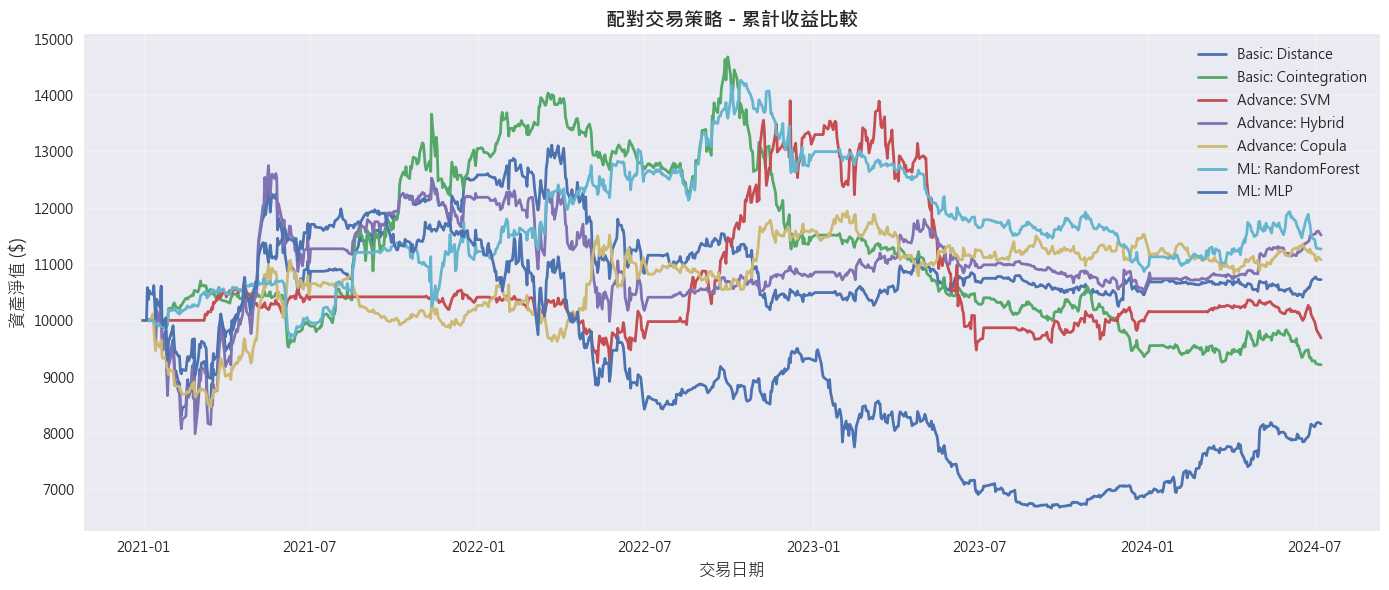

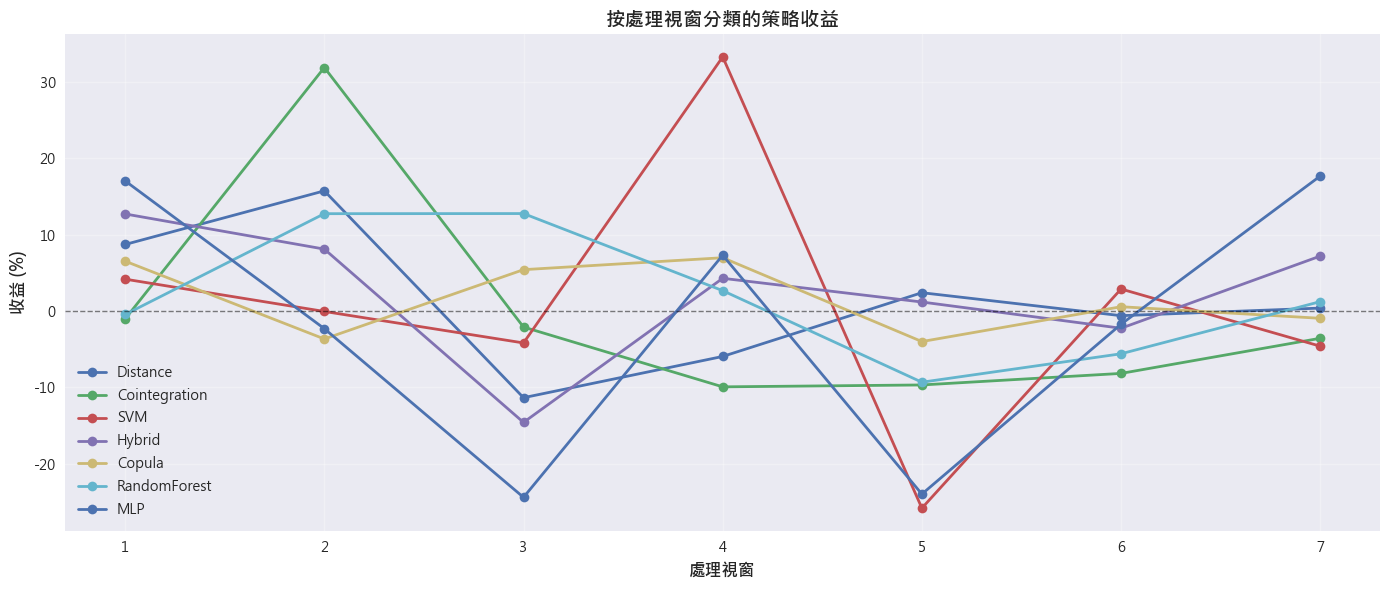

整體策略績效
----------------------------------------------------------------------------------------------------
視窗  1 (2020-12-31): 啟用策略:  7 | 配對總數: 140
視窗  2 (2021-07-02): 啟用策略:  7 | 配對總數: 133
視窗  3 (2021-12-31): 啟用策略:  7 | 配對總數: 136
視窗  4 (2022-07-05): 啟用策略:  7 | 配對總數: 140
視窗  5 (2023-01-03): 啟用策略:  7 | 配對總數: 140
視窗  6 (2023-07-06): 啟用策略:  7 | 配對總數: 129
視窗  7 (2024-01-04): 啟用策略:  7 | 配對總數: 136

處理視窗分析

總處理視窗數: 7

[回測績效摘要]
            Strategy   CAGR Sharpe   MaxDD PnL ($)
     Basic: Distance  2.01%   0.20 -22.31%    $725
Basic: Cointegration -2.30%  -0.07 -37.24%   $-787
        Advance: SVM -0.90%   0.03 -31.86%   $-312
     Advance: Hybrid  4.09%   0.29 -24.25%  $1,514
     Advance: Copula  2.94%   0.28 -16.34%  $1,074
    ML: RandomForest  3.45%   0.31 -23.82%  $1,267
             ML: MLP -5.61%  -0.19 -44.37% $-1,837


,Strategy,CAGR,Sharpe,MaxDD,PnL ($)
0,Basic: Distance,2.01%,0.20,-22.31%,$725
1,Basic: Cointegration,-2.30%,-0.07,-37.24%,$-787
2,Advance: SVM,-0.90%,0.03,-31.86%,$-312
3,Advance: Hybrid,4.09%,0.29,-24.25%,"$1,514"
4,Advance: Copula,2.94%,0.28,-16.34%,"$1,074"
5,ML: RandomForest,3.45%,0.31,-23.82%,"$1,267"
6,ML: MLP,-5.61%,-0.19,-44.37%,"$-1,837"


In [13]:
tickers = get_sp500_tickers()
# 完整股票池
small_tickers = tickers

# ======== 統一參數配置 ========
common_params = {
    'num_pairs': 20,                    # 每個策略的配對數
    'transaction_cost_bps': 25.0,       # 單邊滑點成本 (25 bps)
    'entry_sigma': 2.0,                 # 進場門檻 (標準差單位)
    'entry_z': 2.0,                     # 進場門檻 (z-score)
    'exit_sigma': 0.0,                  # 退出門檻 (標準差單位)
    'exit_z': 0.0,                      # 退出門檻 (z-score)
}

print("=" * 60)
print("🚀 開始進行配對交易回測")
print("=" * 60)
print(f"股票池: {len(small_tickers)} 檔股票")
print(f"策略數量: 7 種")
print("-" * 60)
print("[統一參數]")
for param, value in common_params.items():
    print(f"  {param}: {value}")
print("-" * 60)

# 初始化數據處理器
handler = DataHandler(small_tickers, '2020-01-01', '2024-12-31')

# 定義所有策略 (參數將在回測期間統一)
strategies: List[Strategy] = [
    DistanceStrategy(),
    CointegrationStrategy(),
    SVMStrategy(),
    HybridStrategy(),
    CopulaStrategy(),
    RandomForestSignalStrategy(),
    MLPNonLinearStrategy()
]

# 執行回測並應用統一參數
backtester = Backtester(handler, strategies, common_params=common_params)
backtester.run()

# 生成報告
print("\n[訊息] 回測已完成，正在生成報告...")
metrics_df = backtester.report(total_capital=10000)
print("\n[回測績效摘要]")
print(metrics_df.to_string(index=False))
display_func(metrics_df)
